# Global Statistics Visualizer

Compute player-focused statistics from enriched Chess.com games and visualize them with radar and component charts.

In [1]:
from dataclasses import asdict, is_dataclass
from pathlib import Path

import chess.engine
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.chesscom_repository import ChessComRepository
from utils.game_enrichment_transformer import GameEnrichmentTransformer
from utils.global_statistics_transformer import GlobalStatisticsTransformer
from utils.opening_repository import OpeningRepository

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

In [2]:
# USERNAME = "Sylvathur"
USERNAME = "MagnusCarlsen"
MAX_GAMES = 100
SINCE_YEAR = 2026
SINCE_MONTH = 1

# Choose any subset of: "rapid", "blitz", "bullet".
# Use None to include every time class returned by Chess.com.
TIME_CLASSES = {"rapid"}

# Choose True for rated games, False for unrated games, or None for both.
RATED_FILTER = True

STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"  # Apple Silicon Mac
# STOCKFISH_PATH = "/usr/local/bin/stockfish"   # Intel Mac

OPENINGS_PATH = "openings_dataset/all.tsv"
GLOBAL_STATISTICS_HPARAMS_PATH = "config/global_statistics_hparams.yaml"
ENGINE_DEPTH = 10

In [3]:
chesscom_repo = ChessComRepository(USERNAME)

def game_matches_filters(game_data: dict) -> bool:
    if TIME_CLASSES is not None and game_data.get("time_class") not in TIME_CLASSES:
        return False

    if RATED_FILTER is not None and game_data.get("rated") is not RATED_FILTER:
        return False

    return True


raw_games = []
seen_games = 0
skipped_games = 0
for game_data in chesscom_repo.iter_all_games(
    since_year=SINCE_YEAR,
    since_month=SINCE_MONTH,
):
    seen_games += 1
    if "pgn" not in game_data:
        skipped_games += 1
        continue

    if not game_matches_filters(game_data):
        skipped_games += 1
        continue

    raw_games.append(game_data)
    if len(raw_games) >= MAX_GAMES:
        break

filter_summary = {
    "username": USERNAME,
    "time_classes": "all" if TIME_CLASSES is None else ", ".join(sorted(TIME_CLASSES)),
    "rated": "both" if RATED_FILTER is None else RATED_FILTER,
    "seen_games": seen_games,
    "skipped_games": skipped_games,
    "selected_games": len(raw_games),
}

display(pd.DataFrame([filter_summary]))
print(f"Selected {len(raw_games)} games after filters")
if not raw_games:
    raise RuntimeError("No games found. Check USERNAME, date range, TIME_CLASSES, and RATED_FILTER.")

,username,time_classes,rated,seen_games,skipped_games,selected_games
0,MagnusCarlsen,rapid,True,604,585,19


Selected 19 games after filters


In [4]:
opening_repo = OpeningRepository(OPENINGS_PATH)

enrichment_transformer = GameEnrichmentTransformer(
    stockfish_path=STOCKFISH_PATH,
    opening_repository=opening_repo,
    engine_limit=chess.engine.Limit(depth=ENGINE_DEPTH),
)

enriched_games = enrichment_transformer.transform_games(raw_games)
print(f"Enriched {len(enriched_games)} games")

Enriched 19 games


In [5]:
stats = GlobalStatisticsTransformer(GLOBAL_STATISTICS_HPARAMS_PATH).compute(
    enriched_games,
    username=USERNAME,
)

stats

GlobalStatistics(username='MagnusCarlsen', games_count=19, target_games_count=19, target_moves_count=1047, min_samples=3, complexity_p50=130.15903953761125, complexity_p85=150.73030244833149, complexity_p90=169.7752489678503, tactics_score=StatisticResult(score=0.9846862670945271, average_loss=0.0153137329054729, sample_count=318, game_count=19), calculation_score=StatisticResult(score=0.9851139414251852, average_loss=0.014886058574814821, sample_count=174, game_count=19), openings_score=OpeningStatistics(score=0.7517853353666715, book_accuracy=0.3157894736842105, eval_stability_after_opening=0.9851496181017638, result_from_opening_positions=0.6052631578947368, opening_move_count=190, post_opening_move_count=114, game_count=19), middlegame_strategy_score=StatisticResult(score=0.9806425743551227, average_loss=0.019357425644877302, sample_count=270, game_count=19), endgame_score=StatisticResult(score=0.9849475507828461, average_loss=0.015052449217153893, sample_count=422, game_count=14),

In [6]:
def score_value(section):
    return None if section is None else section.score


skill_scores = {
    "Tactics": score_value(stats.tactics_score),
    "Calculation": score_value(stats.calculation_score),
    "Openings": score_value(stats.openings_score),
    "Middlegame Strategy": score_value(stats.middlegame_strategy_score),
    "Endgame": score_value(stats.endgame_score),
    "Time Management": score_value(stats.time_management_score),
    "Game Analysis": score_value(stats.game_analysis_score),
    "Advantage Capitalization": score_value(stats.advantage_capitalization_score),
    "Resourcefulness": score_value(stats.resourcefulness_score),
}

skill_scores_df = pd.DataFrame(
    [
        {"skill": skill, "score": score, "score_pct": None if score is None else score * 100}
        for skill, score in skill_scores.items()
    ]
)

display(skill_scores_df)

,skill,score,score_pct
0,Tactics,0.984686,98.468627
1,Calculation,0.985114,98.511394
2,Openings,0.751785,75.178534
3,Middlegame Strategy,0.980643,98.064257
4,Endgame,0.984948,98.494755
5,Time Management,0.849046,84.904578
6,Game Analysis,NaN,NaN
7,Advantage Capitalization,0.889625,88.962537
8,Resourcefulness,0.287946,28.794551


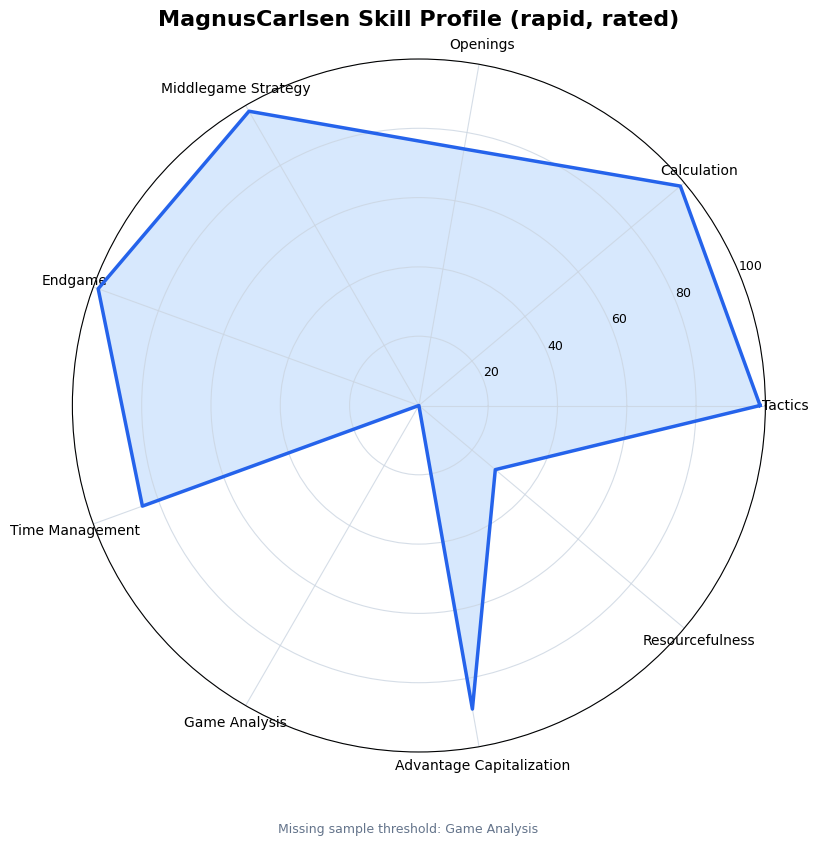

In [7]:
def plot_radar_chart(scores: dict[str, float | None], title: str):
    labels = list(scores.keys())
    values = [0.0 if value is None else float(value) for value in scores.values()]
    missing = [label for label, value in scores.items() if value is None]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values_closed = values + values[:1]
    angles_closed = angles + angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
    ax.plot(angles_closed, values_closed, linewidth=2.5, color="#2563eb")
    ax.fill(angles_closed, values_closed, color="#60a5fa", alpha=0.25)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=9)
    ax.set_title(title, pad=24, fontsize=16, fontweight="bold")
    ax.grid(color="#cbd5e1", alpha=0.8)

    if missing:
        fig.text(
            0.5,
            0.02,
            "Missing sample threshold: " + ", ".join(missing),
            ha="center",
            fontsize=9,
            color="#64748b",
        )

    plt.show()


time_class_label = "all time classes" if TIME_CLASSES is None else ", ".join(sorted(TIME_CLASSES))
rated_label = "rated + unrated" if RATED_FILTER is None else ("rated" if RATED_FILTER else "unrated")

plot_radar_chart(skill_scores, f"{USERNAME} Skill Profile ({time_class_label}, {rated_label})")

In [8]:
def dataclass_to_flat_dict(value, prefix=""):
    if is_dataclass(value):
        value = asdict(value)

    flat = {}
    for key, item in value.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(item, dict):
            flat.update(dataclass_to_flat_dict(item, name))
        else:
            flat[name] = item
    return flat


details = dataclass_to_flat_dict(stats)
details_df = pd.DataFrame(
    [{"metric": metric, "value": value} for metric, value in details.items()]
)

display(details_df)

,metric,value
0,username,MagnusCarlsen
1,games_count,19
2,target_games_count,19
3,target_moves_count,1047
4,min_samples,3
...,...,...
66,resourcefulness_score.survival_moves_before_collapse,5.5
67,resourcefulness_score.low_collapse_rate_when_worse,0.956522
68,resourcefulness_score.worse_game_count,4
69,resourcefulness_score.lost_game_count,0


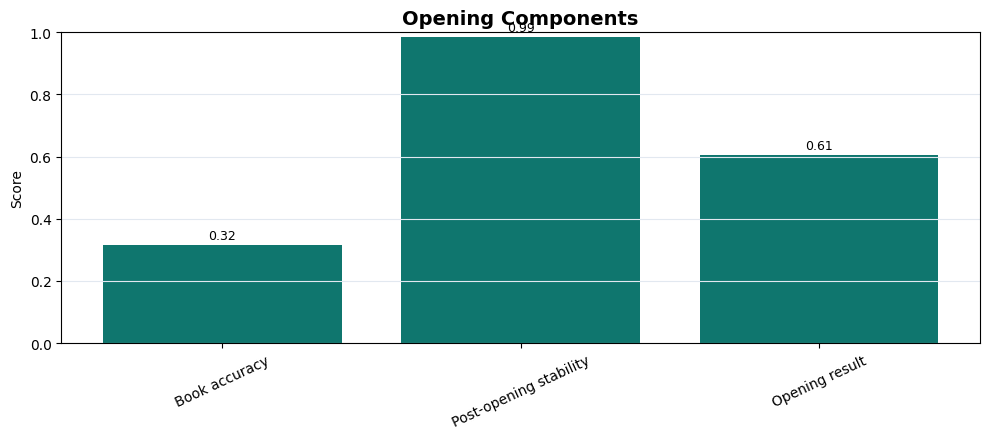

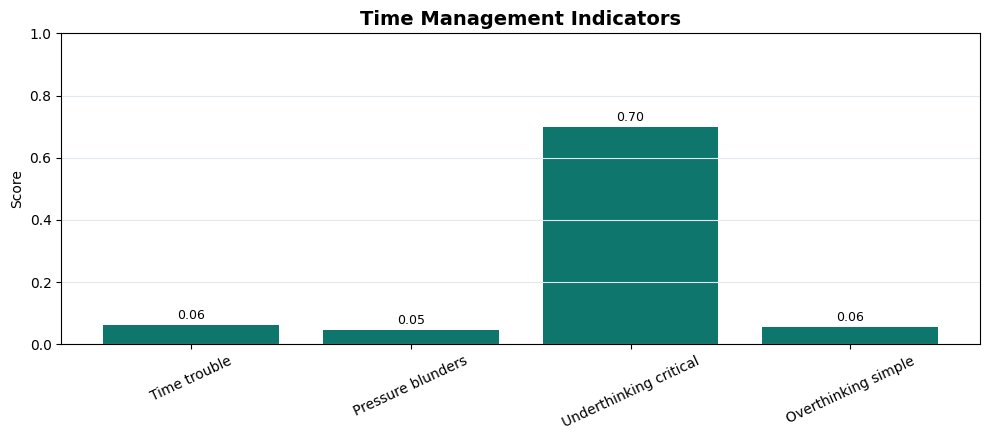

In [9]:
def plot_component_bar(title: str, components: dict[str, float | None], *, as_percent: bool = True):
    labels = list(components.keys())
    values = [0.0 if value is None else float(value) for value in components.values()]
    colors = ["#94a3b8" if value is None else "#0f766e" for value in components.values()]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(labels, values, color=colors)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1 if as_percent else max(values + [1]))
    ax.set_ylabel("Score" if as_percent else "Value")
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(axis="y", color="#e2e8f0")

    for index, value in enumerate(values):
        label = "n/a" if list(components.values())[index] is None else f"{value:.2f}"
        ax.text(index, value + 0.02, label, ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_component_bar(
    "Opening Components",
    {
        "Book accuracy": stats.openings_score.book_accuracy,
        "Post-opening stability": stats.openings_score.eval_stability_after_opening,
        "Opening result": stats.openings_score.result_from_opening_positions,
    },
)

plot_component_bar(
    "Time Management Indicators",
    {
        "Time trouble": stats.time_management_score.time_trouble_frequency,
        "Pressure blunders": stats.time_management_score.blunder_rate_in_time_pressure,
        "Underthinking critical": stats.time_management_score.critical_position_underthinking_rate,
        "Overthinking simple": stats.time_management_score.overthinking_simple_positions_rate,
    },
)

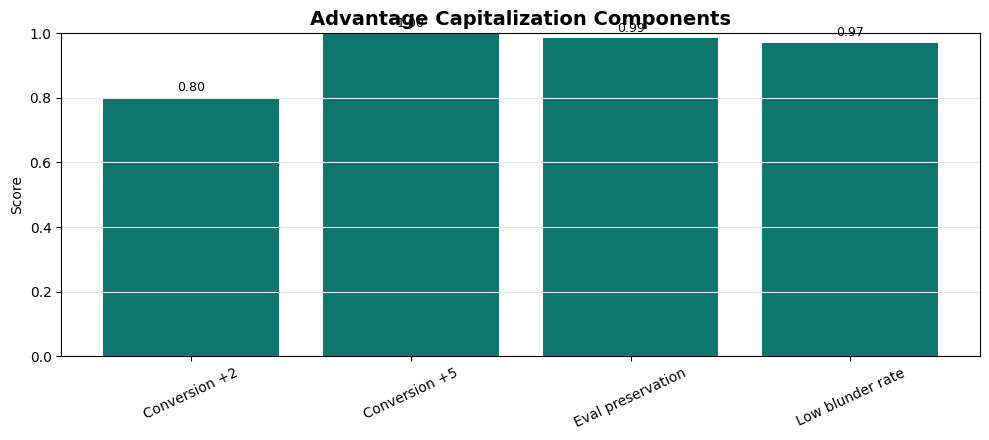

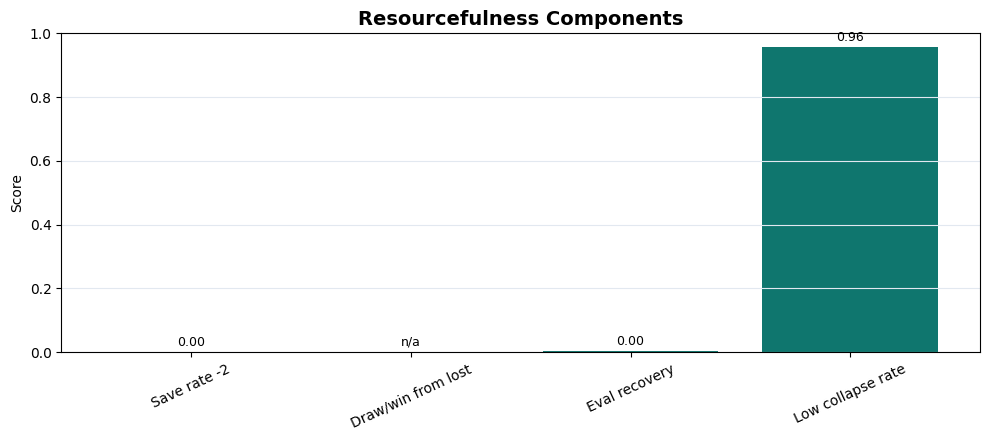

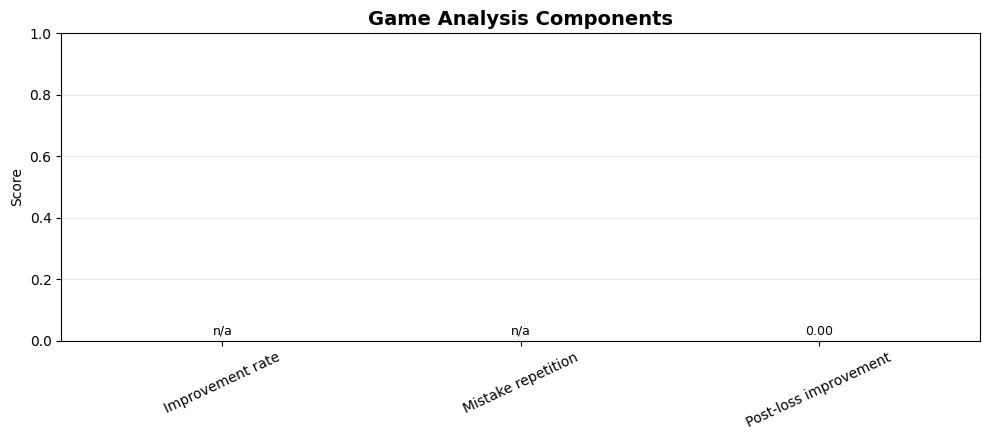

In [10]:
plot_component_bar(
    "Advantage Capitalization Components",
    {
        "Conversion +2": stats.advantage_capitalization_score.conversion_rate_from_plus_2,
        "Conversion +5": stats.advantage_capitalization_score.conversion_rate_from_plus_5,
        "Eval preservation": stats.advantage_capitalization_score.eval_preservation_when_ahead,
        "Low blunder rate": stats.advantage_capitalization_score.low_blunder_rate_when_ahead,
    },
)

plot_component_bar(
    "Resourcefulness Components",
    {
        "Save rate -2": stats.resourcefulness_score.save_rate_from_minus_2,
        "Draw/win from lost": stats.resourcefulness_score.draw_or_win_rate_from_lost_positions,
        "Eval recovery": stats.resourcefulness_score.eval_recovery_rate,
        "Low collapse rate": stats.resourcefulness_score.low_collapse_rate_when_worse,
    },
)

plot_component_bar(
    "Game Analysis Components",
    {
        "Improvement rate": stats.game_analysis_score.weakness_improvement_rate,
        "Mistake repetition": stats.game_analysis_score.mistake_repetition_rate,
        "Post-loss improvement": stats.game_analysis_score.post_loss_improvement,
    },
)

,complexity_bucket,average_seconds
0,simple,7.198496
1,normal,12.718768
2,complex,9.532143
3,high_complexity,4.466949


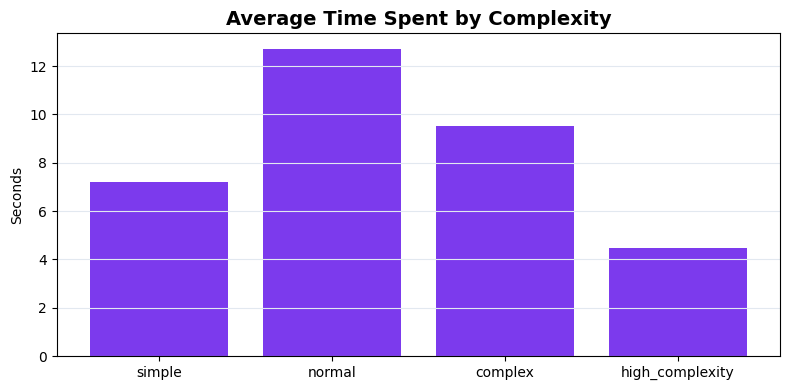

In [11]:
time_by_complexity = stats.time_management_score.average_time_spent_by_complexity
time_by_complexity_df = pd.DataFrame(
    [
        {"complexity_bucket": bucket, "average_seconds": value}
        for bucket, value in time_by_complexity.items()
    ]
)

display(time_by_complexity_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    time_by_complexity_df["complexity_bucket"],
    time_by_complexity_df["average_seconds"].fillna(0),
    color="#7c3aed",
)
ax.set_title("Average Time Spent by Complexity", fontsize=14, fontweight="bold")
ax.set_ylabel("Seconds")
ax.grid(axis="y", color="#e2e8f0")
plt.tight_layout()
plt.show()